# Analisis Profitabilitas per Category (Central)

## Metodologi

1. Memfilter data untuk region Central.
2. Menghitung `profit_margin` untuk masing-masing category.
3. Memvisualisasikan hasil perhitungan.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
# Mengimpor library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

# Memuat data
df = pd.read_csv('superstore.csv')
df['order_date'] = pd.to_datetime(df['order_date'], yearfirst=True, errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], yearfirst=True, errors='coerce')

## Filter Data Region Central

Memfilter data untuk region Central sebagai fokus analisis.

In [2]:
df_central = df[df['region'] == 'Central'].copy()

## Hitung Profit Margin per Category

Mengelompokkan data (`df_central`) berdasarkan category untuk menghitung `profit_margin`.

In [3]:
# Menghitung total sales dan profit untuk masing-masing category
df_agg = df_central.groupby('category').agg(sales=('sales', 'sum'), profit=('profit', 'sum'))

# Menghitung profit margin
df_agg['profit_margin'] = df_agg['profit'].div(df_agg['sales']).mul(100)

df_agg

,sales,profit,profit_margin
category,,,
Furniture,163797.1638,-2871.0494,-1.752808
Office Supplies,167026.4150,8879.9799,5.316512
Technology,169306.8640,33441.9670,19.752281


## Visualisasi Profit Margin per Category

Memvisualisasikan hasil perhitungan dalam bentuk bar chart untuk mengidentifikasi category yang merugi.

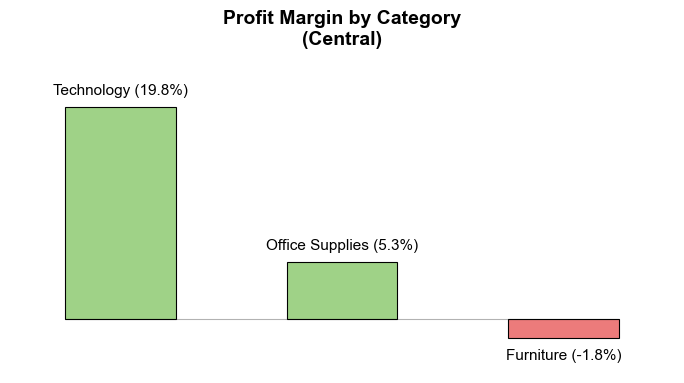

In [4]:
sns.set_theme(style='white')
plt.figure(figsize=(7, 4))
df_agg.sort_values(by='profit_margin', ascending=False, inplace=True)
palette = ['#9ADE7B' if margin > 0 else '#FF6868' for margin in df_agg['profit_margin']]

fig = sns.barplot(x=df_agg.index, y=df_agg['profit_margin'], palette=palette, ec='black', ls='-', lw=0.8)

for bar in fig.patches:
    bar.set_width(0.5)
    bar.set_xy((bar.get_xy()[0] + 0.15, 0))

title_dict = {'size':14,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':0,
              'pad':5,
              'alpha':1,
              'family':plt.rcParams['font.family']}
    
plt.title('Profit Margin by Category\n(Central)', **title_dict)
plt.xlabel('')
plt.ylabel('')

ax = plt.gca()
ax.set_ylim(-5, 25)
ax.set_xticks(ticks=[])
ax.set_yticks(ticks=[])
ax.axhline(y=0, xmin=0.083, xmax=0.917, color='black', ls='-', lw=0.8, alpha=0.3)

container = ax.containers[0]
labels = [f'{category} ({margin:.1f}%)' for category, margin in zip(df_agg.index, df_agg['profit_margin'])]
ax.bar_label(container=container, labels=labels, size=11, weight='normal', color='black', padding=7)

plt.tight_layout()
sns.despine(left=True, bottom=True)
plt.show()